# Reinforcement Learning

In [1]:
#%pip install gymnasium numpy pandas matplotlib seaborn tqdm

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import math
import time
import random
from collections import Counter, defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import gymnasium as gym

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [3]:
SEEDS = [11, 35, 49]

BLACKJACK_CONFIG = {
    "gamma": 0.95,
    "vi_tol": 1e-8,
    "pi_tol": 1e-8,
    "max_iterations": 10000,
    "train_episodes": 30000,
    "eval_episodes": 5000,
    "alpha": 0.05,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.99985,
}

CARTPOLE_DISCRETIZATIONS = {
    "coarse": (4, 4, 8, 8),
    "medium": (6, 6, 12, 12),
    "fine": (8, 8, 16, 16),
}

CARTPOLE_CONFIG = {
    "gamma": 0.99,
    "vi_tol": 1e-6,
    "pi_tol": 1e-6,
    "max_iterations": 200,
    "train_episodes": 2500,
    "eval_episodes": 500,
    "alpha": 0.10,
    "epsilon_start": 1.0,
    "epsilon_min": 0.02,
    "epsilon_decay": 0.997,
    "model_samples_per_action": 1,
}


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)


In [4]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values.copy()
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def epsilon_by_episode(ep, start, min_value, decay):
    return max(min_value, start * (decay ** ep))


def summarize_runs(name, values):
    values = np.asarray(values, dtype=float)
    return {
        "method": name,
        "mean": values.mean(),
        "std": values.std(ddof=0),
        "min": values.min(),
        "max": values.max(),
    }


def plot_learning_curves(curves, title, ylabel="Return", window=100):
    plt.figure(figsize=(8, 5))
    for label, rewards in curves.items():
        smooth = moving_average(rewards, window=window)
        x = np.arange(len(smooth)) + (window if len(rewards) >= window else 1)
        plt.plot(x, smooth, label=label)
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_tabular_policy(env_fn, policy_fn, episodes=1000, seed=11):
    rewards = []
    for ep in range(episodes):
        env = env_fn()
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        while not done:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
        env.close()
    return np.asarray(rewards)

## 1. Blackjack-v1

In [5]:
def make_blackjack_env():
    return gym.make("Blackjack-v1", sab=False, natural=False)


def blackjack_state_space():
    states = []
    for player_sum in range(4, 22):
        for dealer_card in range(1, 11):
            for usable_ace in [0, 1]:
                states.append((player_sum, dealer_card, usable_ace))
    return states


BJ_STATES = blackjack_state_space()
BJ_STATE_TO_IDX = {s: i for i, s in enumerate(BJ_STATES)}
BJ_N_STATES = len(BJ_STATES)
BJ_N_ACTIONS = 2  # 0=stick, 1=hit

CARD_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
CARD_PROBS = {
    1: 1/13,
    2: 1/13,
    3: 1/13,
    4: 1/13,
    5: 1/13,
    6: 1/13,
    7: 1/13,
    8: 1/13,
    9: 1/13,
    10: 4/13,
}


def add_card_to_hand(total, usable_ace, card):
    if card == 1:
        if total + 11 <= 21:
            total += 11
            usable_ace = 1
        else:
            total += 1
    else:
        total += card

    if total > 21 and usable_ace:
        total -= 10
        usable_ace = 0
    return total, usable_ace


def compare_blackjack(player_sum, dealer_sum):
    if player_sum > 21:
        return -1.0
    if dealer_sum > 21:
        return 1.0
    if player_sum > dealer_sum:
        return 1.0
    if player_sum < dealer_sum:
        return -1.0
    return 0.0


@lru_cache(maxsize=None)
def dealer_final_distribution(total, usable_ace):
    if total >= 17:
        return {total: 1.0}

    outcome_probs = defaultdict(float)
    for card, p_card in CARD_PROBS.items():
        new_total, new_usable = add_card_to_hand(total, usable_ace, card)
        if new_total > 21:
            outcome_probs["bust"] += p_card
        else:
            sub_dist = dealer_final_distribution(new_total, new_usable)
            for final_total, p_sub in sub_dist.items():
                outcome_probs[final_total] += p_card * p_sub
    return dict(outcome_probs)


def blackjack_transition_model():
    P = {s_idx: {0: [], 1: []} for s_idx in range(BJ_N_STATES)}

    for state in BJ_STATES:
        player_sum, dealer_showing, usable_ace = state
        s_idx = BJ_STATE_TO_IDX[state]

        # Action 1: hit
        hit_transitions = []
        for card, p_card in CARD_PROBS.items():
            new_sum, new_usable = add_card_to_hand(player_sum, usable_ace, card)
            if new_sum > 21:
                hit_transitions.append((p_card, None, -1.0, True))
            else:
                next_state = (new_sum, dealer_showing, new_usable)
                hit_transitions.append((p_card, BJ_STATE_TO_IDX[next_state], 0.0, False))
        P[s_idx][1] = hit_transitions

        # Action 0: stick
        reward_dist = defaultdict(float)
        for hidden_card, p_hidden in CARD_PROBS.items():
            dealer_total, dealer_usable = 0, 0
            dealer_total, dealer_usable = add_card_to_hand(dealer_total, dealer_usable, dealer_showing)
            dealer_total, dealer_usable = add_card_to_hand(dealer_total, dealer_usable, hidden_card)
            final_dist = dealer_final_distribution(dealer_total, dealer_usable)
            for dealer_final, p_final in final_dist.items():
                reward = compare_blackjack(player_sum, 22 if dealer_final == "bust" else dealer_final)
                reward_dist[reward] += p_hidden * p_final

        P[s_idx][0] = [(prob, None, reward, True) for reward, prob in reward_dist.items()]
    return P


BJ_P = blackjack_transition_model()
print(f"Blackjack states: {BJ_N_STATES}")

Blackjack states: 360


In [6]:
def value_iteration(P, n_states, n_actions, gamma=0.99, tol=1e-8, max_iterations=10000):
    V = np.zeros(n_states, dtype=float)
    deltas = []

    for _ in range(max_iterations):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(n_states):
            q_values = []
            for a in range(n_actions):
                q_sa = 0.0
                for prob, next_state, reward, done in P[s][a]:
                    next_value = 0.0 if done or next_state is None else V[next_state]
                    q_sa += prob * (reward + gamma * next_value)
                q_values.append(q_sa)
            V_new[s] = max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        deltas.append(delta)
        if delta < tol:
            break

    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = []
        for a in range(n_actions):
            q_sa = 0.0
            for prob, next_state, reward, done in P[s][a]:
                next_value = 0.0 if done or next_state is None else V[next_state]
                q_sa += prob * (reward + gamma * next_value)
            q_values.append(q_sa)
        policy[s] = int(np.argmax(q_values))

    return V, policy, deltas


def policy_evaluation(P, policy, n_states, gamma=0.99, tol=1e-8, max_iterations=10000):
    V = np.zeros(n_states, dtype=float)
    for _ in range(max_iterations):
        delta = 0.0
        for s in range(n_states):
            a = int(policy[s])
            v_new = 0.0
            for prob, next_state, reward, done in P[s][a]:
                next_value = 0.0 if done or next_state is None else V[next_state]
                v_new += prob * (reward + gamma * next_value)
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < tol:
            break
    return V


def policy_iteration(P, n_states, n_actions, gamma=0.99, tol=1e-8, max_iterations=10000):
    policy = np.zeros(n_states, dtype=int)
    value_deltas = []
    policy_changes = []

    for _ in range(max_iterations):
        V = policy_evaluation(P, policy, n_states, gamma=gamma, tol=tol, max_iterations=max_iterations)
        stable = True
        n_changes = 0
        q_cache = np.zeros((n_states, n_actions), dtype=float)

        for s in range(n_states):
            old_action = int(policy[s])
            for a in range(n_actions):
                q_sa = 0.0
                for prob, next_state, reward, done in P[s][a]:
                    next_value = 0.0 if done or next_state is None else V[next_state]
                    q_sa += prob * (reward + gamma * next_value)
                q_cache[s, a] = q_sa
            policy[s] = int(np.argmax(q_cache[s]))
            if policy[s] != old_action:
                stable = False
                n_changes += 1

        value_deltas.append(np.max(np.abs(V - q_cache.max(axis=1))))
        policy_changes.append(n_changes)
        if stable:
            break

    V = policy_evaluation(P, policy, n_states, gamma=gamma, tol=tol, max_iterations=max_iterations)
    return V, policy, value_deltas, policy_changes

### Blackjack: Dynamic Programming

In [7]:
start = time.time()
BJ_V_vi, BJ_policy_vi, BJ_vi_deltas = value_iteration(
    BJ_P,
    n_states=BJ_N_STATES,
    n_actions=BJ_N_ACTIONS,
    gamma=BLACKJACK_CONFIG["gamma"],
    tol=BLACKJACK_CONFIG["vi_tol"],
    max_iterations=BLACKJACK_CONFIG["max_iterations"],
)
bj_vi_time = time.time() - start

start = time.time()
BJ_V_pi, BJ_policy_pi, BJ_pi_value_deltas, BJ_pi_policy_changes = policy_iteration(
    BJ_P,
    n_states=BJ_N_STATES,
    n_actions=BJ_N_ACTIONS,
    gamma=BLACKJACK_CONFIG["gamma"],
    tol=BLACKJACK_CONFIG["pi_tol"],
    max_iterations=BLACKJACK_CONFIG["max_iterations"],
)
bj_pi_time = time.time() - start

blackjack_dp_summary = pd.DataFrame([
    {"method": "Value Iteration", "iterations": len(BJ_vi_deltas), "time_sec": bj_vi_time},
    {"method": "Policy Iteration", "iterations": len(BJ_pi_policy_changes), "time_sec": bj_pi_time},
])
blackjack_dp_summary

,method,iterations,time_sec
0,Value Iteration,12,0.037939
1,Policy Iteration,3,0.056941


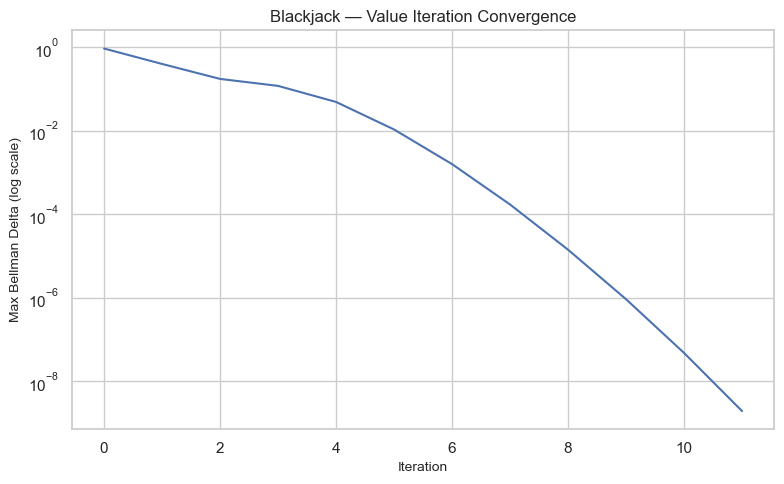

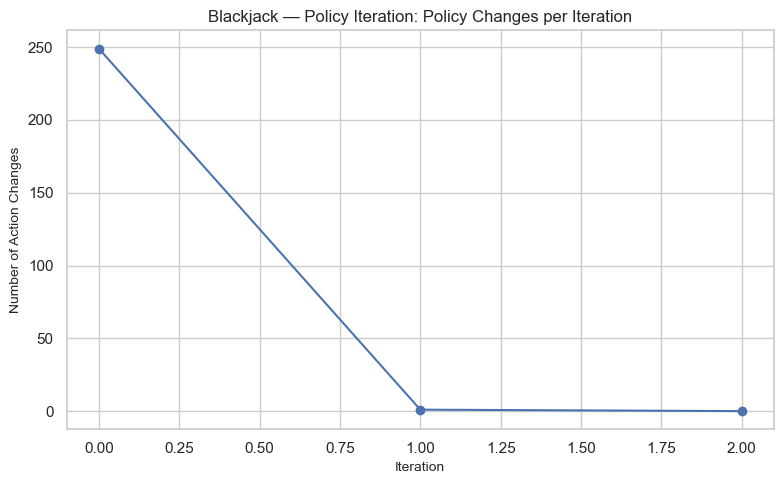

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(BJ_vi_deltas)
plt.yscale("log")
plt.title("Blackjack — Value Iteration Convergence")
plt.xlabel("Iteration")
plt.ylabel("Max Bellman Delta (log scale)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(BJ_pi_policy_changes, marker="o")
plt.title("Blackjack — Policy Iteration: Policy Changes per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Number of Action Changes")
plt.tight_layout()
plt.show()

In [9]:
def blackjack_policy_fn_from_array(policy_array):
    def policy_fn(obs):
        player_sum, dealer_card, usable_ace = obs
        state = (int(player_sum), int(dealer_card), int(usable_ace))
        return int(policy_array[BJ_STATE_TO_IDX[state]])
    return policy_fn


bj_vi_eval = evaluate_tabular_policy(
    make_blackjack_env,
    blackjack_policy_fn_from_array(BJ_policy_vi),
    episodes=BLACKJACK_CONFIG["eval_episodes"],
    seed=11,
)

bj_pi_eval = evaluate_tabular_policy(
    make_blackjack_env,
    blackjack_policy_fn_from_array(BJ_policy_pi),
    episodes=BLACKJACK_CONFIG["eval_episodes"],
    seed=11,
)

pd.DataFrame([
    summarize_runs("VI policy", bj_vi_eval),
    summarize_runs("PI policy", bj_pi_eval),
])

,method,mean,std,min,max
0,VI policy,-0.046,0.953249,-1.0,1.0
1,PI policy,-0.046,0.953249,-1.0,1.0


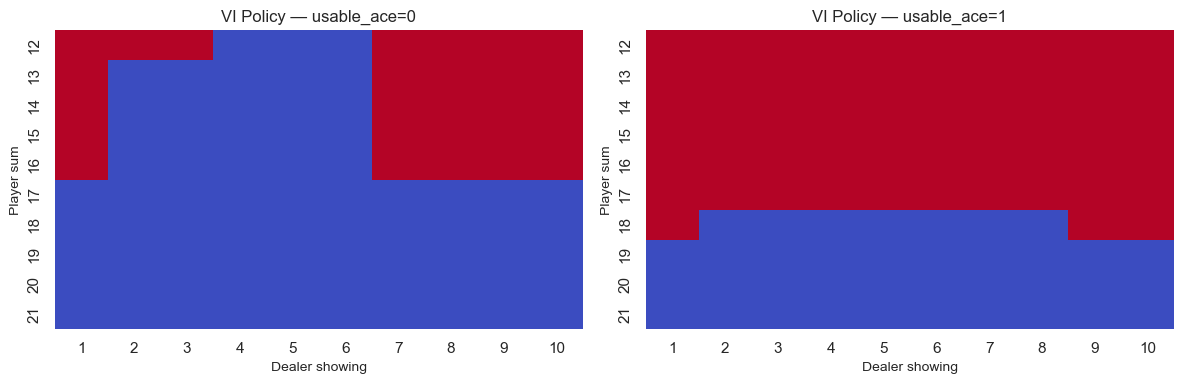

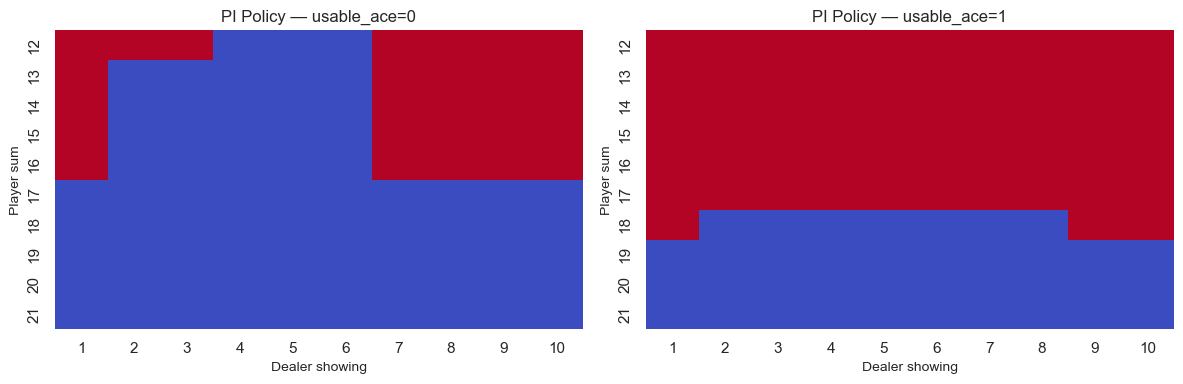

In [10]:
def blackjack_policy_grid(policy_array, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            grid[i, j] = policy_array[BJ_STATE_TO_IDX[(ps, dc, int(usable_ace))]]
    return pd.DataFrame(grid, index=player_sums, columns=dealer_cards)


for title, policy_array in [("VI", BJ_policy_vi), ("PI", BJ_policy_pi)]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, usable in zip(axes, [0, 1]):
        grid = blackjack_policy_grid(policy_array, usable)
        sns.heatmap(grid, cmap="coolwarm", cbar=False, ax=ax)
        ax.set_title(f"{title} Policy - usable_ace={usable}")
        ax.set_xlabel("Dealer showing")
        ax.set_ylabel("Player sum")
    plt.tight_layout()
    plt.show()

### Blackjack — SARSA and Q-Learning

In [12]:
def train_blackjack_td(method="q_learning", seed=11, config=None):
    assert method in {"q_learning", "sarsa"}
    config = config or BLACKJACK_CONFIG
    set_global_seed(seed)

    q_table = np.zeros((BJ_N_STATES, BJ_N_ACTIONS), dtype=float)
    rewards = []

    env = make_blackjack_env()
    for ep in tqdm(range(config["train_episodes"]), desc=f"Blackjack {method} seed={seed}", leave=False):
        epsilon = epsilon_by_episode(ep, config["epsilon_start"], config["epsilon_min"], config["epsilon_decay"])
        obs, _ = env.reset(seed=seed + ep)
        state = BJ_STATE_TO_IDX[(int(obs[0]), int(obs[1]), int(obs[2]))]

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))

        done = False
        total_reward = 0.0
        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            alpha = config["alpha"]
            gamma = config["gamma"]

            if done:
                target = reward
                q_table[state, action] += alpha * (target - q_table[state, action])
            else:
                next_state = BJ_STATE_TO_IDX[(int(next_obs[0]), int(next_obs[1]), int(next_obs[2]))]
                if method == "q_learning":
                    target = reward + gamma * np.max(q_table[next_state])
                    q_table[state, action] += alpha * (target - q_table[state, action])
                    next_action = None
                else:
                    if np.random.rand() < epsilon:
                        next_action = env.action_space.sample()
                    else:
                        next_action = int(np.argmax(q_table[next_state]))
                    target = reward + gamma * q_table[next_state, next_action]
                    q_table[state, action] += alpha * (target - q_table[state, action])

                state = next_state
                if method == "q_learning":
                    if np.random.rand() < epsilon:
                        action = env.action_space.sample()
                    else:
                        action = int(np.argmax(q_table[state]))
                else:
                    action = next_action

        rewards.append(total_reward)
    env.close()
    return q_table, rewards


def blackjack_policy_from_q(q_table):
    policy = np.argmax(q_table, axis=1)
    return blackjack_policy_fn_from_array(policy)


In [13]:
blackjack_td_results = {}
blackjack_td_learning_curves = {}

for method in ["sarsa", "q_learning"]:
    eval_scores = []
    seed_curves = []
    for seed in SEEDS:
        q_table, rewards = train_blackjack_td(method=method, seed=seed, config=BLACKJACK_CONFIG)
        seed_curves.append(rewards)
        eval_rewards = evaluate_tabular_policy(
            make_blackjack_env,
            blackjack_policy_from_q(q_table),
            episodes=BLACKJACK_CONFIG["eval_episodes"],
            seed=seed,
        )
        eval_scores.append(eval_rewards.mean())
    blackjack_td_results[method] = eval_scores
    blackjack_td_learning_curves[method] = np.mean(np.asarray(seed_curves), axis=0)

pd.DataFrame([
    summarize_runs("SARSA", blackjack_td_results["sarsa"]),
    summarize_runs("Q-Learning", blackjack_td_results["q_learning"]),
])

Blackjack sarsa seed=11:   0%|          | 0/30000 [00:00<?, ?it/s]

Blackjack sarsa seed=35:   0%|          | 0/30000 [00:00<?, ?it/s]

Blackjack sarsa seed=49:   0%|          | 0/30000 [00:00<?, ?it/s]

Blackjack q_learning seed=11:   0%|          | 0/30000 [00:00<?, ?it/s]

Blackjack q_learning seed=35:   0%|          | 0/30000 [00:00<?, ?it/s]

Blackjack q_learning seed=49:   0%|          | 0/30000 [00:00<?, ?it/s]

,method,mean,std,min,max
0,SARSA,-0.056667,0.006329,-0.0654,-0.0506
1,Q-Learning,-0.063400,0.004525,-0.0698,-0.0602


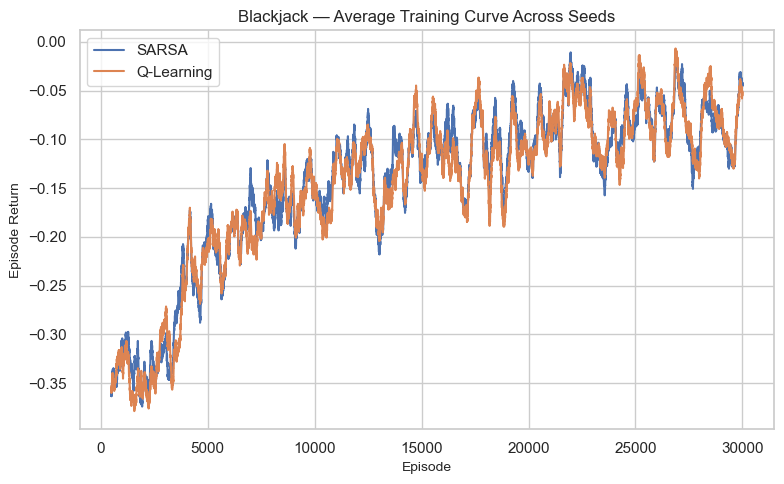

In [14]:
plot_learning_curves(
    {
        "SARSA": blackjack_td_learning_curves["sarsa"],
        "Q-Learning": blackjack_td_learning_curves["q_learning"],
    },
    title="Blackjack — Average Training Curve Across Seeds",
    ylabel="Episode Return",
    window=500,
)

In [15]:
blackjack_final_summary = pd.DataFrame([
    summarize_runs("VI", bj_vi_eval),
    summarize_runs("PI", bj_pi_eval),
    summarize_runs("SARSA", blackjack_td_results["sarsa"]),
    summarize_runs("Q-Learning", blackjack_td_results["q_learning"]),
])
blackjack_final_summary

,method,mean,std,min,max
0,VI,-0.046000,0.953249,-1.0000,1.0000
1,PI,-0.046000,0.953249,-1.0000,1.0000
2,SARSA,-0.056667,0.006329,-0.0654,-0.0506
3,Q-Learning,-0.063400,0.004525,-0.0698,-0.0602


## 2. CartPole-v1

In [17]:
def make_cartpole_env():
    return gym.make("CartPole-v1")


class CartPoleDiscretizer:
    def __init__(self, bins=(6, 6, 12, 12), low=None, high=None):
        self.bins = tuple(int(x) for x in bins)
        self.low = np.array(low if low is not None else [-4.8, -3.0, -0.418, -4.0], dtype=float)
        self.high = np.array(high if high is not None else [4.8, 3.0, 0.418, 4.0], dtype=float)
        self.edges = [
            np.linspace(self.low[i], self.high[i], self.bins[i] + 1)[1:-1]
            for i in range(4)
        ]
        self.centers = [
            (np.linspace(self.low[i], self.high[i], self.bins[i] + 1)[:-1] + np.linspace(self.low[i], self.high[i], self.bins[i] + 1)[1:]) / 2
            for i in range(4)
        ]
        self.n_states = int(np.prod(self.bins))

    def discretize_tuple(self, obs):
        obs = np.clip(np.asarray(obs, dtype=float), self.low, self.high)
        idxs = [int(np.digitize(obs[i], self.edges[i])) for i in range(4)]
        return tuple(idxs)

    def tuple_to_index(self, idx_tuple):
        return np.ravel_multi_index(idx_tuple, self.bins)

    def index_to_tuple(self, idx):
        return tuple(np.unravel_index(idx, self.bins))

    def discretize_index(self, obs):
        return self.tuple_to_index(self.discretize_tuple(obs))

    def representative_state(self, idx_tuple):
        return np.array([self.centers[i][idx_tuple[i]] for i in range(4)], dtype=float)

    def sample_from_bin(self, idx_tuple, rng):
        sample = []
        for i, b in enumerate(idx_tuple):
            left = self.low[i] if b == 0 else self.edges[i][b - 1]
            right = self.high[i] if b == self.bins[i] - 1 else self.edges[i][b]
            sample.append(rng.uniform(left, right))
        return np.asarray(sample, dtype=float)

### CartPole — Approximate MDP for VI / PI

In [18]:
def build_cartpole_transition_model(discretizer, samples_per_action=4, seed=11):
    env = make_cartpole_env()
    rng = np.random.default_rng(seed)
    P = {s: {0: [], 1: []} for s in range(discretizer.n_states)}

    for s in tqdm(range(discretizer.n_states), desc=f"Building model {discretizer.bins}"):
        idx_tuple = discretizer.index_to_tuple(s)
        for action in [0, 1]:
            counter = Counter()
            for _ in range(samples_per_action):
                env.reset(seed=seed)
                env.unwrapped.state = discretizer.sample_from_bin(idx_tuple, rng)
                env.unwrapped.steps_beyond_terminated = None

                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                next_state = None if done else discretizer.discretize_index(next_obs)
                counter[(next_state, float(reward), done)] += 1

            total = sum(counter.values())
            transitions = []
            for (next_state, reward, done), count in counter.items():
                transitions.append((count / total, next_state, reward, done))
            P[s][action] = transitions
    env.close()
    return P

In [19]:
cartpole_dp_results = {}
cartpole_dp_models = {}

for name in ["coarse", "medium", "fine"]:
    disc = CartPoleDiscretizer(CARTPOLE_DISCRETIZATIONS[name])
    P = build_cartpole_transition_model(
        disc,
        samples_per_action=CARTPOLE_CONFIG["model_samples_per_action"],
        seed=11,
    )
    cartpole_dp_models[name] = (disc, P)

    start = time.time()
    V_vi, policy_vi, vi_deltas = value_iteration(
        P,
        n_states=disc.n_states,
        n_actions=2,
        gamma=CARTPOLE_CONFIG["gamma"],
        tol=CARTPOLE_CONFIG["vi_tol"],
        max_iterations=CARTPOLE_CONFIG["max_iterations"],
    )
    vi_time = time.time() - start

    start = time.time()
    V_pi, policy_pi, pi_value_deltas, pi_policy_changes = policy_iteration(
        P,
        n_states=disc.n_states,
        n_actions=2,
        gamma=CARTPOLE_CONFIG["gamma"],
        tol=CARTPOLE_CONFIG["pi_tol"],
        max_iterations=CARTPOLE_CONFIG["max_iterations"],
    )
    pi_time = time.time() - start

    cartpole_dp_results[name] = {
        "discretizer": disc,
        "P": P,
        "vi": {"V": V_vi, "policy": policy_vi, "deltas": vi_deltas, "time": vi_time},
        "pi": {"V": V_pi, "policy": policy_pi, "value_deltas": pi_value_deltas, "policy_changes": pi_policy_changes, "time": pi_time},
    }


Building model (4, 4, 8, 8):   0%|          | 0/1024 [00:00<?, ?it/s]

/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Building model (6, 6, 12, 12):   0%|          | 0/5184 [00:00<?, ?it/s]

Building model (8, 8, 16, 16):   0%|          | 0/16384 [00:00<?, ?it/s]

In [20]:
cartpole_dp_summary_rows = []
for name, result in cartpole_dp_results.items():
    cartpole_dp_summary_rows.extend([
        {
            "discretization": name,
            "method": "Value Iteration",
            "iterations": len(result["vi"]["deltas"]),
            "time_sec": result["vi"]["time"],
        },
        {
            "discretization": name,
            "method": "Policy Iteration",
            "iterations": len(result["pi"]["policy_changes"]),
            "time_sec": result["pi"]["time"],
        },
    ])
cartpole_dp_summary = pd.DataFrame(cartpole_dp_summary_rows)
cartpole_dp_summary

,discretization,method,iterations,time_sec
0,coarse,Value Iteration,200,0.341320
1,coarse,Policy Iteration,200,41.570274
2,medium,Value Iteration,200,1.841016
3,medium,Policy Iteration,200,216.755506
4,fine,Value Iteration,200,5.052988
5,fine,Policy Iteration,200,620.054146


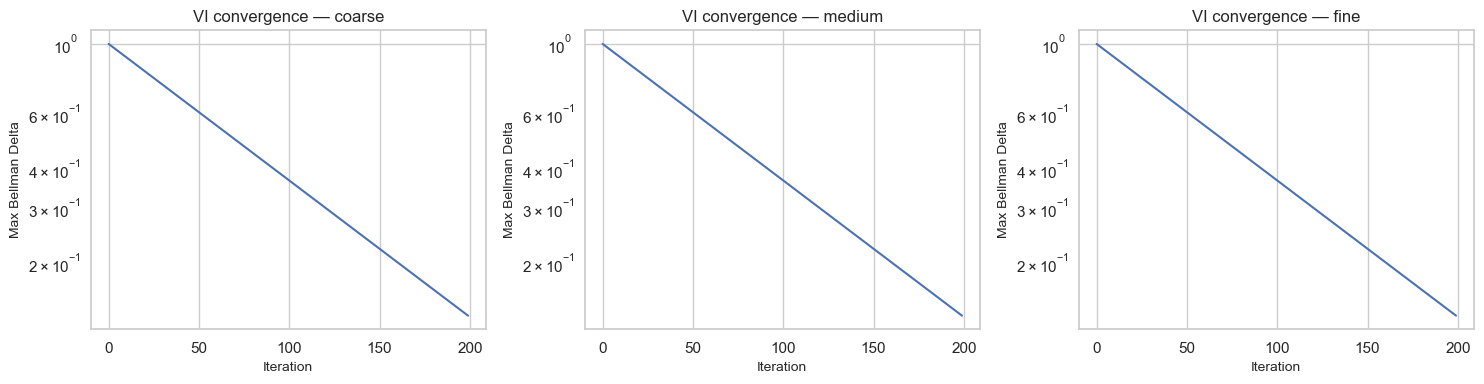

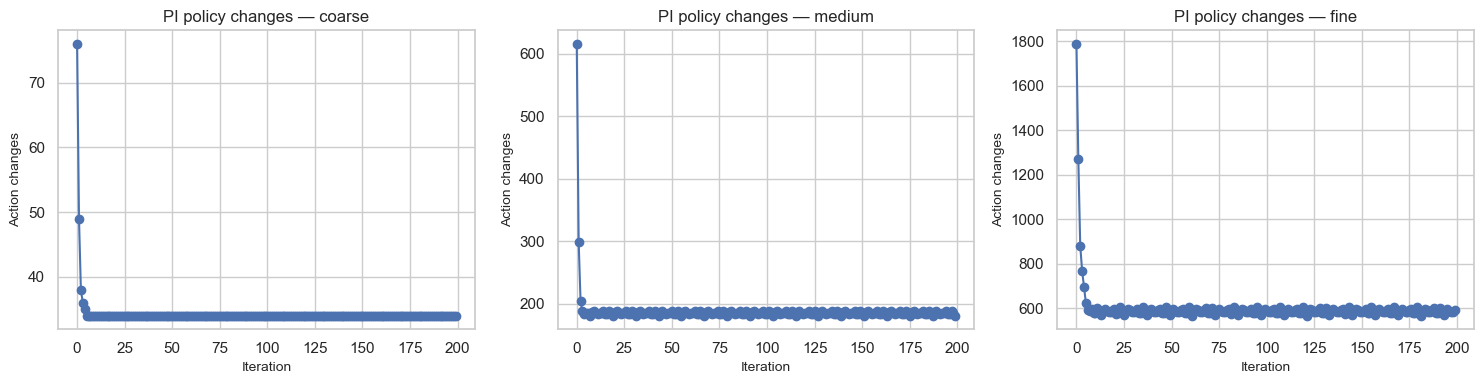

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, name in zip(axes, ["coarse", "medium", "fine"]):
    ax.plot(cartpole_dp_results[name]["vi"]["deltas"])
    ax.set_yscale("log")
    ax.set_title(f"VI convergence — {name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Max Bellman Delta")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, name in zip(axes, ["coarse", "medium", "fine"]):
    ax.plot(cartpole_dp_results[name]["pi"]["policy_changes"], marker="o")
    ax.set_title(f"PI policy changes — {name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Action changes")
plt.tight_layout()
plt.show()

In [22]:
def cartpole_policy_fn_from_array(policy_array, discretizer):
    def policy_fn(obs):
        state = discretizer.discretize_index(obs)
        return int(policy_array[state])
    return policy_fn


cartpole_dp_eval_rows = []
for name, result in cartpole_dp_results.items():
    disc = result["discretizer"]
    for method_key, label in [("vi", "VI"), ("pi", "PI")]:
        eval_rewards = evaluate_tabular_policy(
            make_cartpole_env,
            cartpole_policy_fn_from_array(result[method_key]["policy"], disc),
            episodes=CARTPOLE_CONFIG["eval_episodes"],
            seed=11,
        )
        cartpole_dp_eval_rows.append({
            "discretization": name,
            "method": label,
            "mean_return": eval_rewards.mean(),
            "std_return": eval_rewards.std(ddof=0),
        })
cartpole_dp_eval = pd.DataFrame(cartpole_dp_eval_rows)
cartpole_dp_eval

,discretization,method,mean_return,std_return
0,coarse,VI,9.332,0.744161
1,coarse,PI,12.478,18.000264
2,medium,VI,9.334,0.741919
3,medium,PI,44.568,55.034402
4,fine,VI,10.416,1.153665
5,fine,PI,74.850,62.868176


### CartPole — SARSA and Q-Learning

In [23]:
def train_cartpole_td(discretizer, method="q_learning", seed=11, config=None):
    assert method in {"q_learning", "sarsa"}
    config = config or CARTPOLE_CONFIG
    set_global_seed(seed)

    q_table = np.zeros((discretizer.n_states, 2), dtype=float)
    rewards = []

    env = make_cartpole_env()
    for ep in tqdm(range(config["train_episodes"]), desc=f"CartPole {method} {discretizer.bins} seed={seed}", leave=False):
        epsilon = epsilon_by_episode(ep, config["epsilon_start"], config["epsilon_min"], config["epsilon_decay"])
        obs, _ = env.reset(seed=seed + ep)
        state = discretizer.discretize_index(obs)

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))

        done = False
        total_reward = 0.0
        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            alpha = config["alpha"]
            gamma = config["gamma"]

            if done:
                target = reward
                q_table[state, action] += alpha * (target - q_table[state, action])
            else:
                next_state = discretizer.discretize_index(next_obs)
                if method == "q_learning":
                    target = reward + gamma * np.max(q_table[next_state])
                    q_table[state, action] += alpha * (target - q_table[state, action])
                    if np.random.rand() < epsilon:
                        next_action = env.action_space.sample()
                    else:
                        next_action = int(np.argmax(q_table[next_state]))
                else:
                    if np.random.rand() < epsilon:
                        next_action = env.action_space.sample()
                    else:
                        next_action = int(np.argmax(q_table[next_state]))
                    target = reward + gamma * q_table[next_state, next_action]
                    q_table[state, action] += alpha * (target - q_table[state, action])

                state = next_state
                action = next_action
        rewards.append(total_reward)
    env.close()
    return q_table, rewards


def cartpole_policy_from_q(q_table, discretizer):
    policy = np.argmax(q_table, axis=1)
    return cartpole_policy_fn_from_array(policy, discretizer)

In [24]:
cartpole_td_results = []
cartpole_td_curves = {}

for disc_name, bins in CARTPOLE_DISCRETIZATIONS.items():
    discretizer = CartPoleDiscretizer(bins)
    for method in ["sarsa", "q_learning"]:
        seed_scores = []
        seed_curves = []
        for seed in SEEDS:
            q_table, rewards = train_cartpole_td(discretizer, method=method, seed=seed, config=CARTPOLE_CONFIG)
            seed_curves.append(rewards)
            eval_rewards = evaluate_tabular_policy(
                make_cartpole_env,
                cartpole_policy_from_q(q_table, discretizer),
                episodes=CARTPOLE_CONFIG["eval_episodes"],
                seed=seed,
            )
            seed_scores.append(eval_rewards.mean())
        cartpole_td_results.append({
            "discretization": disc_name,
            "method": method,
            "mean_return": float(np.mean(seed_scores)),
            "std_return": float(np.std(seed_scores, ddof=0)),
        })
        cartpole_td_curves[(disc_name, method)] = np.mean(np.asarray(seed_curves), axis=0)

cartpole_td_summary = pd.DataFrame(cartpole_td_results)
cartpole_td_summary

CartPole sarsa (4, 4, 8, 8) seed=11:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole sarsa (4, 4, 8, 8) seed=35:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole sarsa (4, 4, 8, 8) seed=49:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole q_learning (4, 4, 8, 8) seed=11:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole q_learning (4, 4, 8, 8) seed=35:   0%|          | 0/2500 [00:00<?, ?it/s]

...

CartPole sarsa (8, 8, 16, 16) seed=49:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole q_learning (8, 8, 16, 16) seed=11:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole q_learning (8, 8, 16, 16) seed=35:   0%|          | 0/2500 [00:00<?, ?it/s]

CartPole q_learning (8, 8, 16, 16) seed=49:   0%|          | 0/2500 [00:00<?, ?it/s]

,discretization,method,mean_return,std_return
0,coarse,sarsa,215.473333,63.492011
1,coarse,q_learning,213.731333,95.839348
2,medium,sarsa,153.006667,53.296181
3,medium,q_learning,196.329333,34.500662
4,fine,sarsa,93.598667,41.895277
5,fine,q_learning,94.414667,40.344699


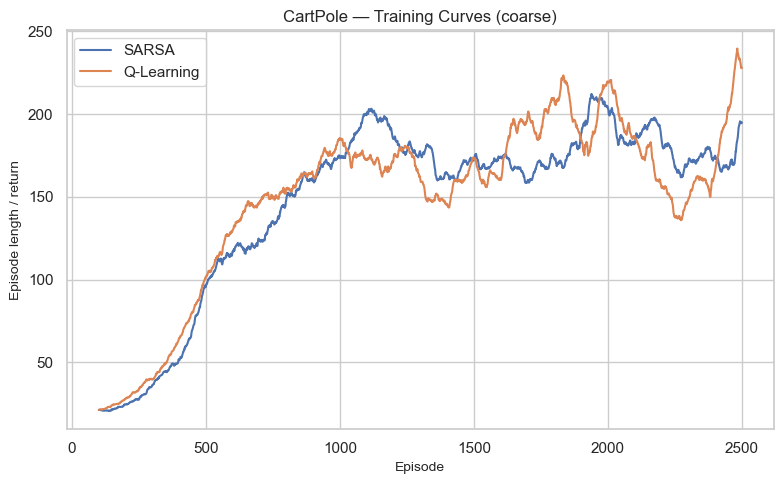

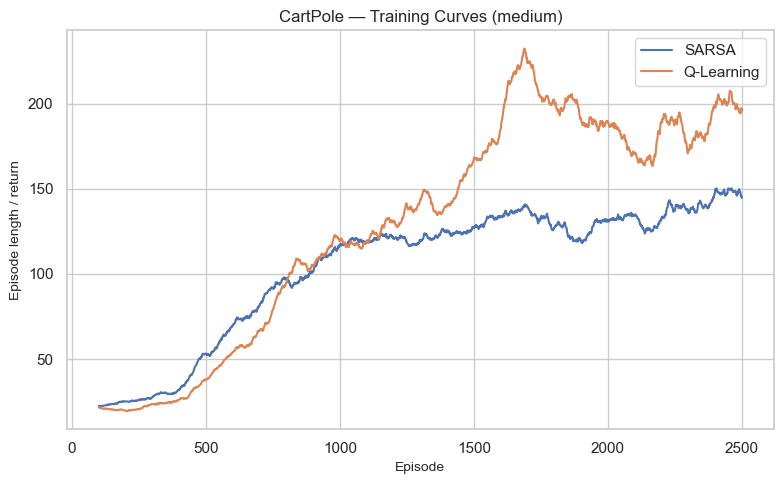

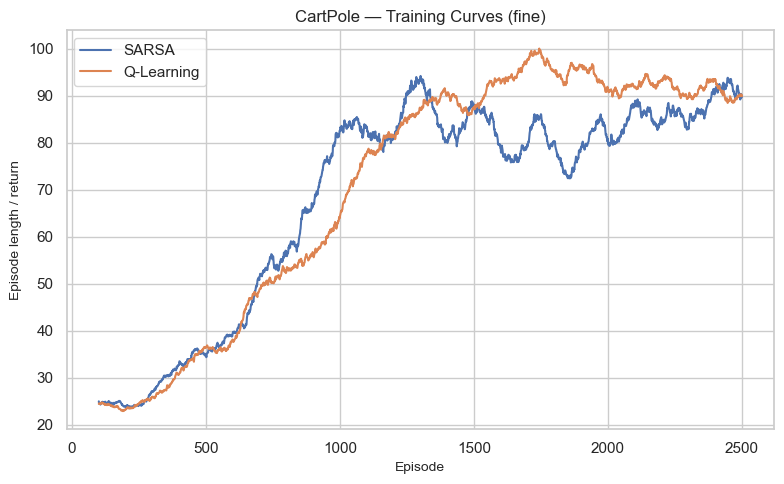

In [25]:
for disc_name in CARTPOLE_DISCRETIZATIONS:
    plot_learning_curves(
        {
            "SARSA": cartpole_td_curves[(disc_name, "sarsa")],
            "Q-Learning": cartpole_td_curves[(disc_name, "q_learning")],
        },
        title=f"CartPole — Training Curves ({disc_name})",
        ylabel="Episode length / return",
        window=100,
    )

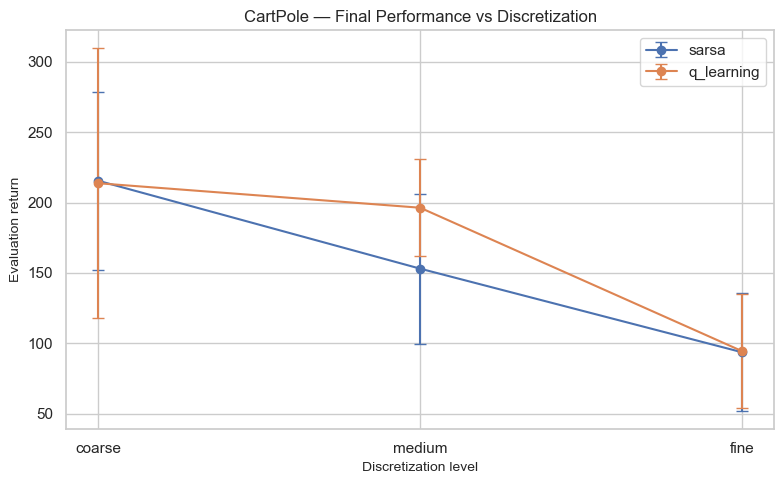

In [26]:
plt.figure(figsize=(8, 5))
for method in ["sarsa", "q_learning"]:
    subset = cartpole_td_summary[cartpole_td_summary["method"] == method]
    plt.errorbar(
        subset["discretization"],
        subset["mean_return"],
        yerr=subset["std_return"],
        marker="o",
        capsize=4,
        label=method,
    )
plt.title("CartPole — Final Performance vs Discretization")
plt.xlabel("Discretization level")
plt.ylabel("Evaluation return")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Final Comparison Tables